In [8]:
!pip install -q yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 3.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 43.3 MB/s eta 0:00:0000:0100:01


In [10]:
import os
import matplotlib.pyplot as plt
from collections import Counter

In [11]:
import yt_dlp
def download_captions(video_url, lang='en', output_dir='/kaggle/working'):

    ydl_opts = {
        'skip_download': True,          
        'writesubtitles': True,
        'writeautomaticsub': True,
        'subtitleslangs': [lang],
        'outtmpl': os.path.join(output_dir, '%(id)s.%(ext)s')
    }
    
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(video_url, download=True)
        video_id = info['id']
        caption_file = os.path.join(output_dir, f"{video_id}.{lang}.vtt")
        if os.path.exists(caption_file):
            print(f"Captions downloaded: {caption_file}")
            return caption_file
        else:
            print("Captions not found!")
            return None


In [12]:
# Replace with your YouTube video URL
video_url = "https://youtu.be/h3M00JI8Iwo?si=aMdEGCrJrgIbZiIC"

caption_file = download_captions(video_url)

# Rename to captions.vtt for consistency
if caption_file:
    os.rename(caption_file, "/kaggle/working/captions.vtt")
    print("Renamed caption file to captions.vtt")


[youtube] Extracting URL: https://youtu.be/h3M00JI8Iwo?si=aMdEGCrJrgIbZiIC
[youtube] h3M00JI8Iwo: Downloading webpage


[youtube] h3M00JI8Iwo: Downloading android sdkless player API JSON
[youtube] h3M00JI8Iwo: Downloading web safari player API JSON


[youtube] h3M00JI8Iwo: Downloading m3u8 information


[info] h3M00JI8Iwo: Downloading subtitles: en
[info] h3M00JI8Iwo: Downloading 1 format(s): 399+251
[info] Writing video subtitles to: /kaggle/working/h3M00JI8Iwo.en.vtt
[download] Destination: /kaggle/working/h3M00JI8Iwo.en.vtt
[download] 100% of   23.90KiB in 00:00:00 at 391.85KiB/s
Captions downloaded: /kaggle/working/h3M00JI8Iwo.en.vtt
Renamed caption file to captions.vtt


In [13]:
def load_vtt_captions(filepath="captions.vtt"):
    captions = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if (
                not line
                or "WEBVTT" in line
                or "-->" in line
                or line.isdigit()
                or "Kind:" in line
                or "Language:" in line
            ):
                continue
            # Remove inline timestamps like <00:00:05.920>
            while "<" in line and ">" in line:
                start = line.find("<")
                end = line.find(">", start)
                if end != -1:
                    line = line[:start] + line[end + 1:]
                else:
                    break
            line = line.strip()
            if line:
                captions.append(line)
    return captions

raw_captions = load_vtt_captions("/kaggle/working/captions.vtt")
print(f"Loaded {len(raw_captions)} caption lines")
print("Sample captions:", raw_captions[:5])


Loaded 492 caption lines
Sample captions: ["I am billed as the world's", 'greatest mind reader.', 'But guess what?', "I can't read minds.", 'What I can do is read people.']


In [15]:
def load_raw_comments(filepath):
    comments = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if len(line) > 2:
                comments.append(line)
    return comments

# Replace 'YOUR_DATASET' with your Kaggle dataset folder name
raw_comments = load_raw_comments("/kaggle/input/commments/Comments.txt")
print(f"Loaded {len(raw_comments)} comment lines")
print("Sample comments:", raw_comments[:5])


Loaded 1988 comment lines
Sample comments: ['@milojadez', '14 hours ago', 'There are people out there that actually are able to read minds and solve murders unexplainably, this guy just found his way to gain from it.', 'Reply', '@JasonWestaway']


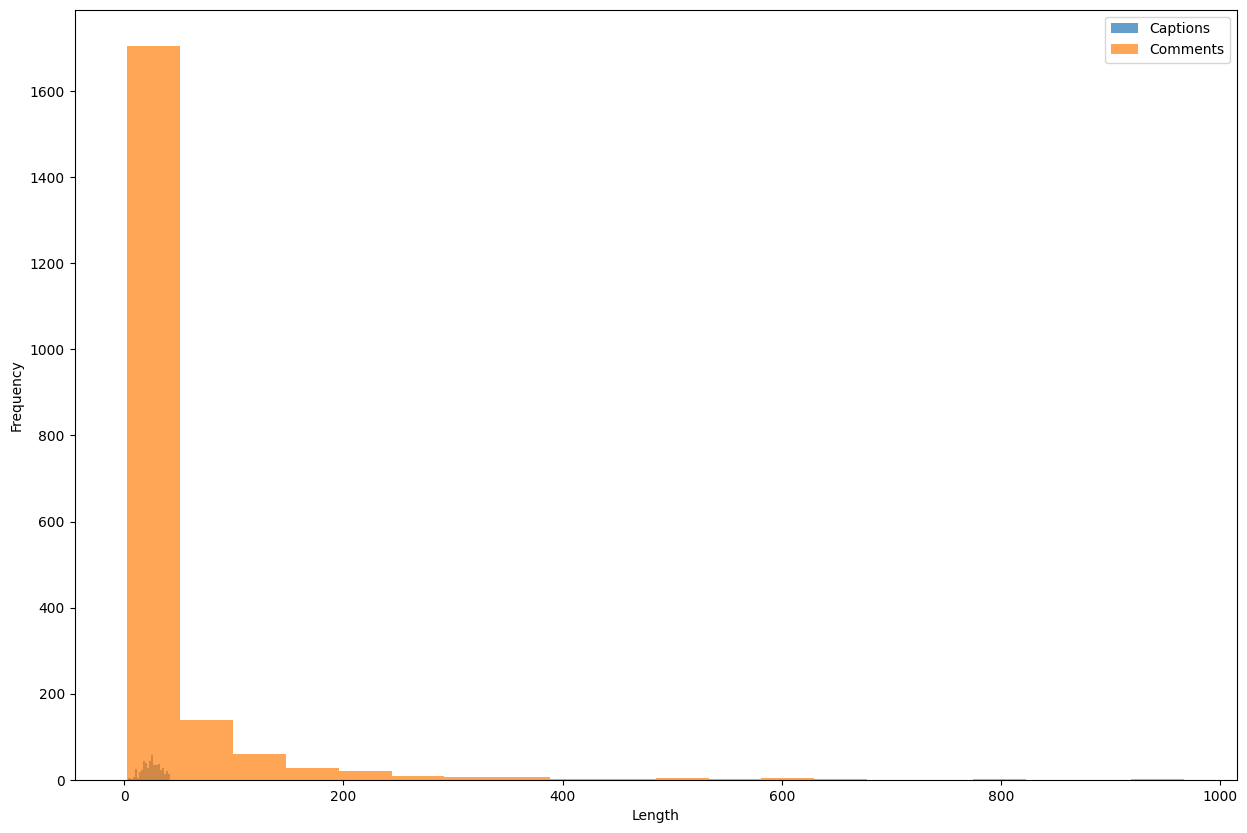

In [16]:
caption_lengths = [len(x) for x in raw_captions]
comment_lengths = [len(x) for x in raw_comments]

plt.figure(figsize=(15,10))
plt.hist(caption_lengths, bins=20, alpha=0.7, label="Captions")
plt.hist(comment_lengths, bins=20, alpha=0.7, label="Comments")
plt.legend()
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


In [17]:
def type_token_ratio(lines):
    words = [word.lower() for line in lines for word in line.split()]
    unique_words = set(words)
    return len(unique_words)/len(words) if words else 0

print("Caption TTR:", type_token_ratio(raw_captions))
print("Comment TTR:", type_token_ratio(raw_comments))

Caption TTR: 0.3695652173913043
Comment TTR: 0.2725375988872468


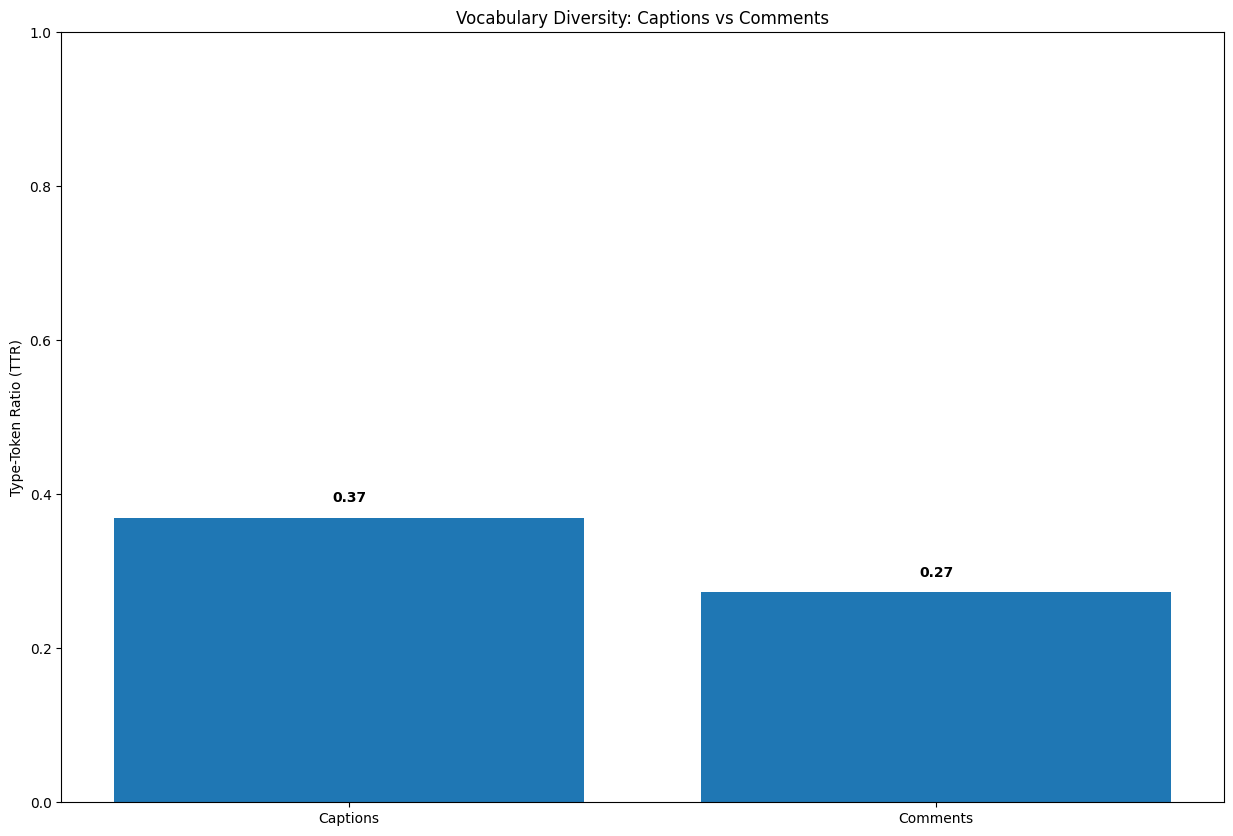

In [18]:
import matplotlib.pyplot as plt

# Function to calculate TTR
def type_token_ratio(lines):
    words = [word.lower() for line in lines for word in line.split()]
    unique_words = set(words)
    return len(unique_words)/len(words) if words else 0

# Calculate TTR
ttr_captions = type_token_ratio(raw_captions)
ttr_comments = type_token_ratio(raw_comments)

# Bar plot
plt.figure(figsize=(15,10))
plt.bar(['Captions', 'Comments'], [ttr_captions, ttr_comments])
plt.ylim(0, 1)  # TTR is always between 0 and 1
plt.ylabel("Type-Token Ratio (TTR)")
plt.title("Vocabulary Diversity: Captions vs Comments")

for i, v in enumerate([ttr_captions, ttr_comments]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

In [22]:
from collections import Counter
stopwords = {
    "the","and","a","is","in","to","of","that","it",
    "on","for","with","as","this","was","but","are",
    "not","be","at","by","an","if","or","from","so","we"
}

def top_n_words(lines, n=20):
    words = [
        word.lower()
        for line in lines
        for word in line.split()
        if word.lower() not in stopwords
    ]
    return Counter(words).most_common(n)

# ---------- Print caption words ----------
print("Top 20 caption words:")
for word, count in top_n_words(raw_captions):
    print(word, ":", count)

# ---------- Print comment words ----------
print("\nTop 20 comment words:")
for word, count in top_n_words(raw_comments):
    print(word, ":", count)


Top 20 caption words:
you : 84
i : 75
your : 35
(laughter) : 19
what : 17
going : 17
op: : 16
have : 15
my : 12
do : 11
see : 11
give : 11
me : 11
he : 11
am : 10
like : 10
person : 10
name : 10
first : 10
can : 9

Top 20 comment words:
reply : 490
ago : 471
1 : 380
month : 357
i : 188
he : 172
you : 101
his : 62
weeks : 61
how : 58
just : 55
like : 53
people : 51
days : 49
have : 47
what : 43
my : 42
2 : 39
all : 38
do : 37


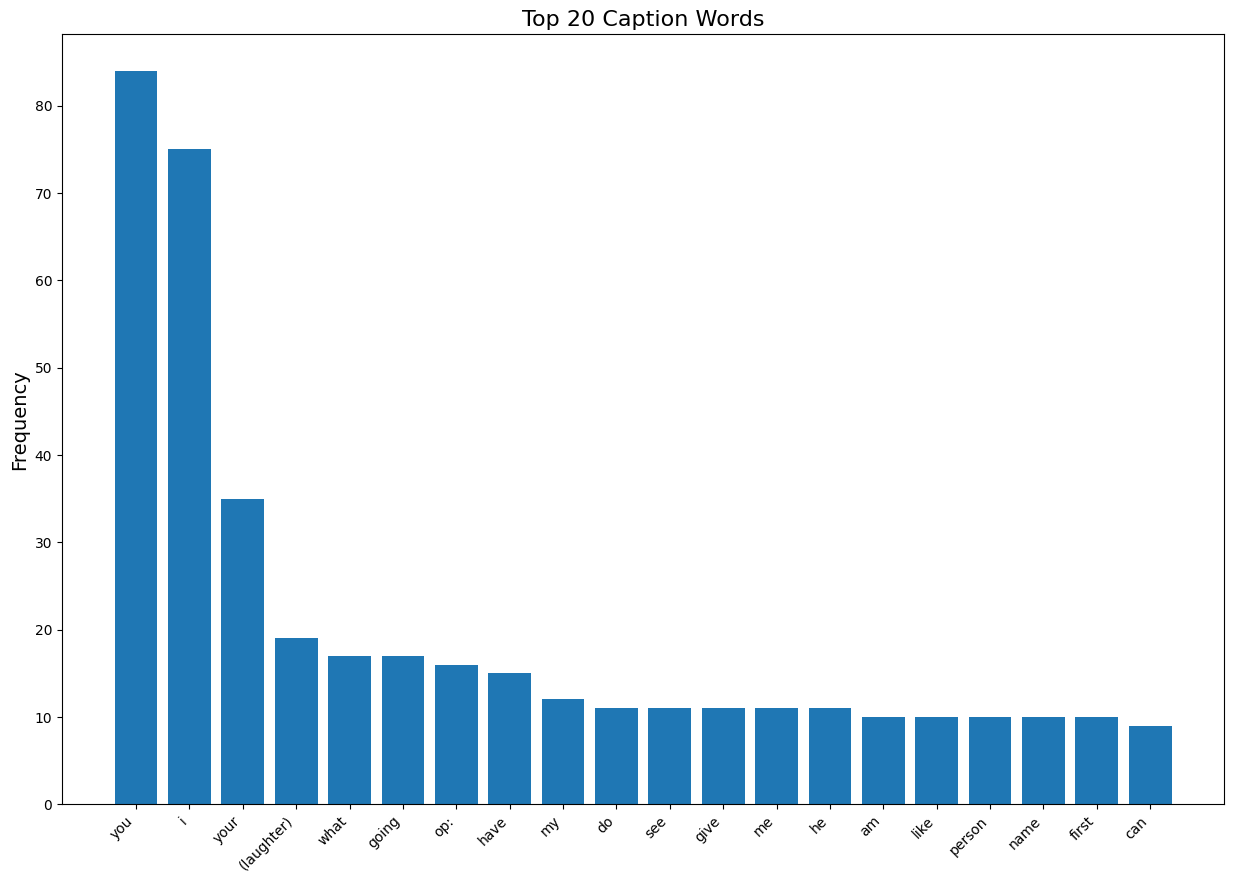

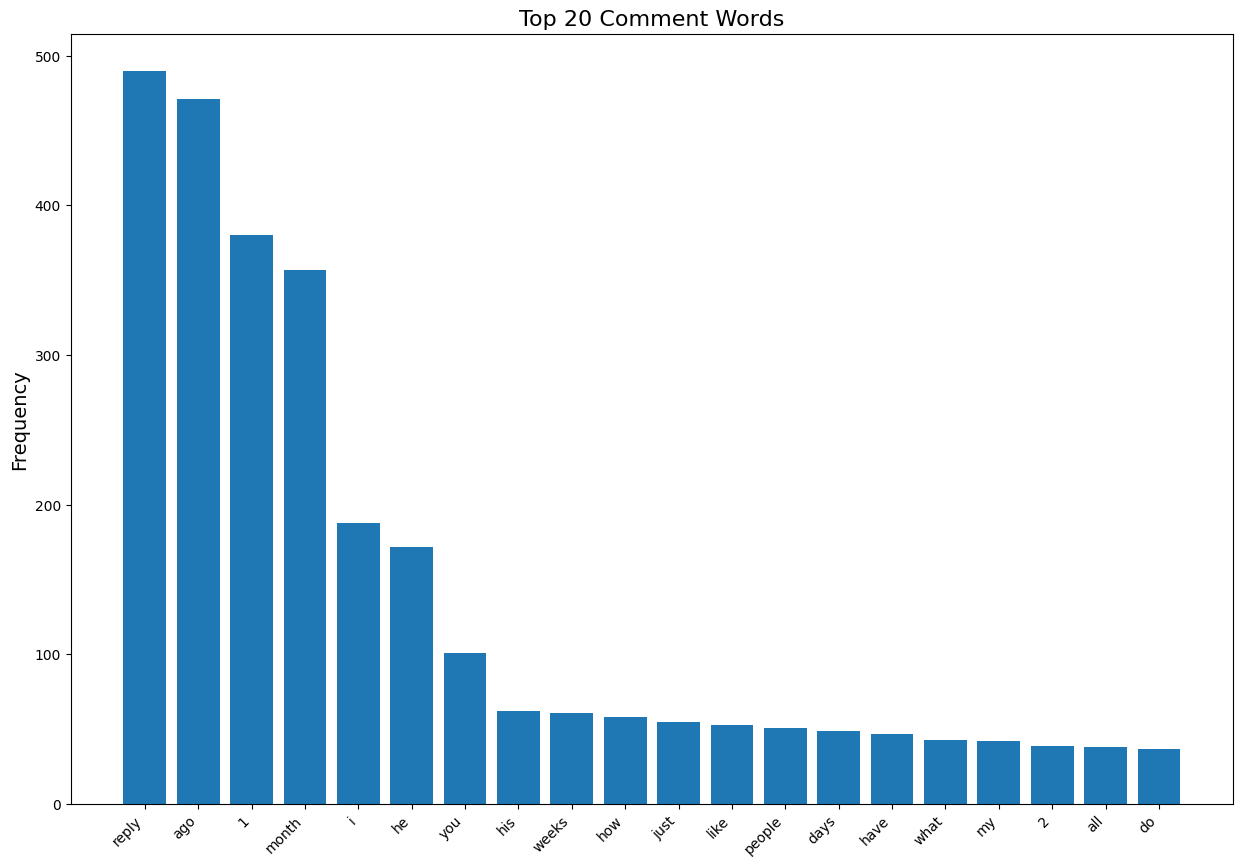

In [23]:
import matplotlib.pyplot as plt
from collections import Counter

# Function to get top N words
def top_n_words(lines, n=20, stopwords=None):
    if stopwords is None:
        stopwords = set()
    words = [word.lower() for line in lines for word in line.split() if word.lower() not in stopwords]
    return Counter(words).most_common(n)

# Stopwords set
stopwords = {
    "the","and","a","is","in","to","of","that","it",
    "on","for","with","as","this","was","but","are",
    "not","be","at","by","an","if","or","from","so","we"
}

# Top 20 words
top_captions = top_n_words(raw_captions, n=20, stopwords=stopwords)
top_comments = top_n_words(raw_comments, n=20, stopwords=stopwords)

# Plot for Captions
words_c, counts_c = zip(*top_captions)
plt.figure(figsize=(15,10))
plt.bar(words_c, counts_c)
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Caption Words", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.show()

# Plot for Comments
words_cm, counts_cm = zip(*top_comments)
plt.figure(figsize=(15,10))
plt.bar(words_cm, counts_cm)
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Comment Words", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.show()


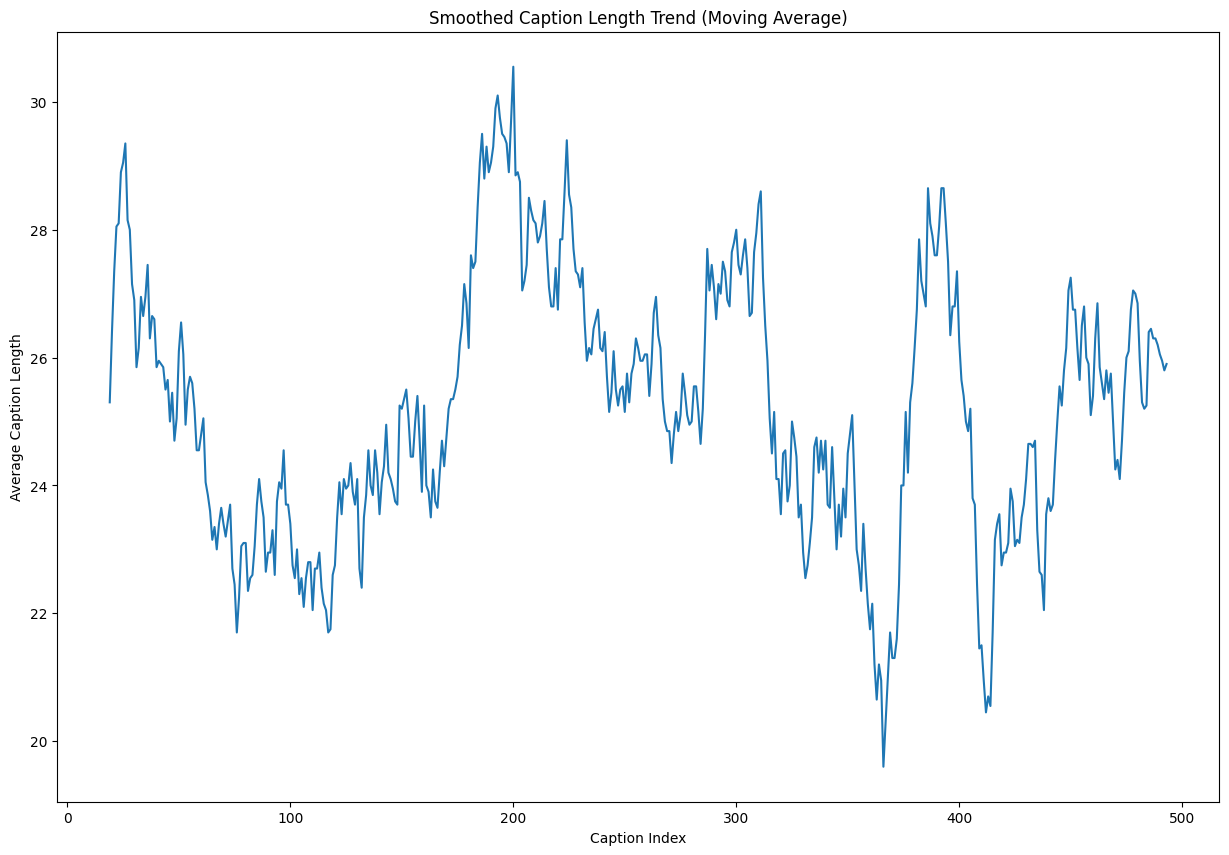

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Load captions (.vtt file) ----------
captions_path = "/kaggle/working/captions.vtt"

with open(captions_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

captions = []
for line in lines:
    line = line.strip()
    if line == "" or "-->" in line or line.isdigit() or line.startswith("WEBVTT"):
        continue
    captions.append(line)

# ---------- Create DataFrame ----------
df_captions = pd.DataFrame({"caption": captions})

# ---------- Add caption length ----------
df_captions['caption_len'] = df_captions['caption'].apply(len)

# ---------- Moving Average (window = 20) ----------
df_captions['caption_len_ma'] = (
    df_captions['caption_len']
    .rolling(window=20)
    .mean()
)

# ---------- Plot ----------
plt.figure(figsize=(15, 10))

plt.plot(
    df_captions['caption_len_ma']
)

plt.title("Smoothed Caption Length Trend (Moving Average)")
plt.xlabel("Caption Index")
plt.ylabel("Average Caption Length")

plt.show()


/tmp/ipykernel_55/2947361902.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


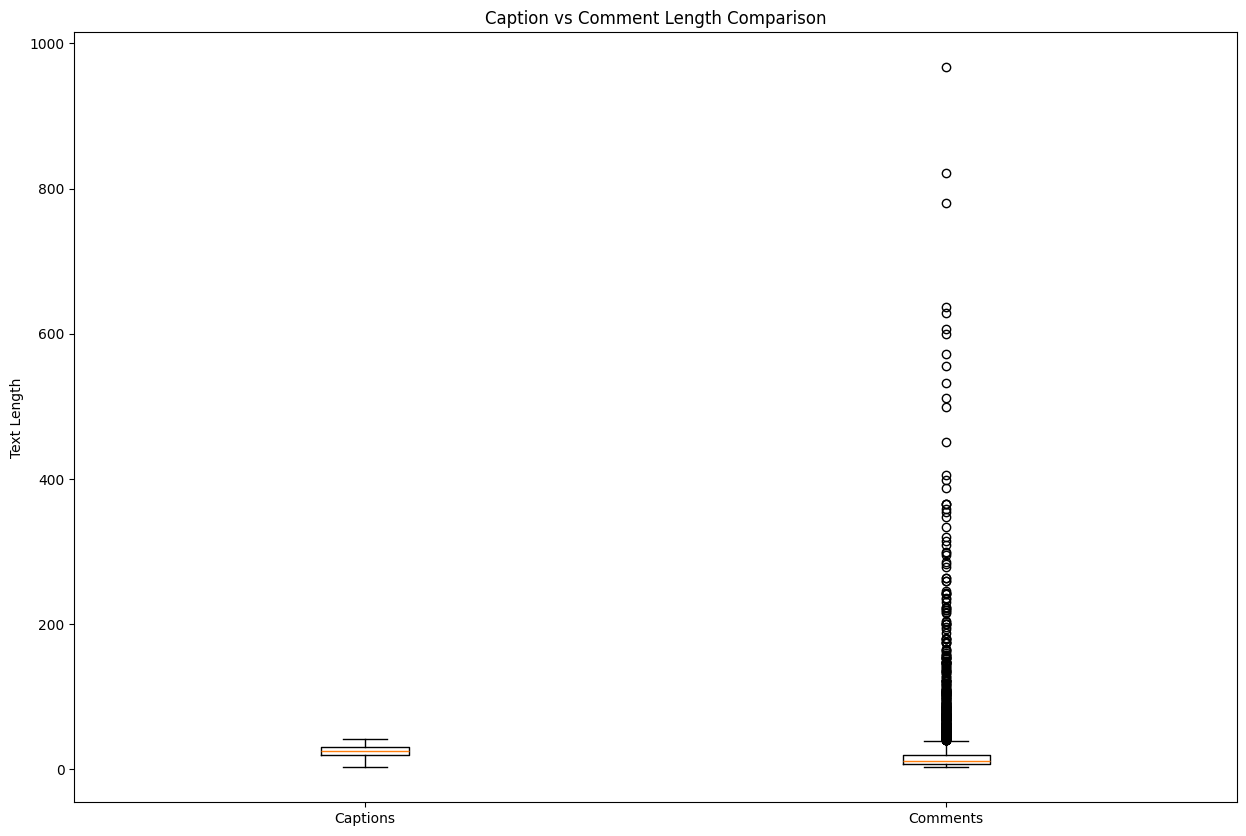

In [29]:
plt.figure(figsize=(15, 10))

plt.boxplot(
    [caption_lengths, comment_lengths],
    labels=['Captions', 'Comments']
)

plt.ylabel("Text Length")
plt.title("Caption vs Comment Length Comparison")

plt.show()
